In [1]:
!pip install pandas --quiet


In [2]:
import pandas as pd

In [3]:
medical_df = pd.read_csv('hospital.csv', sep=',')

In [4]:
#Split the single column into multiple columns
medical_df = medical_df.iloc[:, 0].str.split(',', expand=True)

#Set proper column names
medical_df.columns = ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges']

#Convert numeric columns
medical_df['age'] = pd.to_numeric(medical_df['age'])
medical_df['bmi'] = pd.to_numeric(medical_df['bmi'])
medical_df['children'] = pd.to_numeric(medical_df['children'])
medical_df['charges'] = pd.to_numeric(medical_df['charges'])

#Check the result
medical_df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
medical_df.shape
medical_df.info()
medical_df['age'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [6]:
print(medical_df.columns)
Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype = )

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


NameError: name 'Index' is not defined

In [7]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
!pip install plotly matplotlib seaborn --quiet

In [11]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#matplot lib for graphs
#seaborn for better graphs and statistics
#plotly for interactivity

In [12]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [14]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [15]:
fig = px.histogram(medical_df, x='age', marginal='box', nbins=47, title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

#px is plotly express

In [16]:
fig = px.histogram(medical_df, x='bmi', marginal='box', color_discrete_sequence=['red'], title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

#We are using histogram only instead of other graphs
#for frequency distribution analysis and to compare two values

In [17]:
fig = px.histogram(medical_df, x='charges', marginal='box', color='smoker', color_discrete_sequence=['green','grey'], title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [18]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [19]:
px.histogram(medical_df, x = 'smoker', color='gender', title="Smoker")


In [21]:
fig = px.scatter(medical_df, x='age', y='charges', color='smoker', opacity=0.8, hover_data=['gender'], title='Age vs Charges')
fig.update_traces(marker_size=5)
fig.show()

#opacity to create slightly transparent dots
#hover to show info about a point when hovered

In [22]:
fig = px.scatter(medical_df, x='bmi', y='charges', color='smoker', opacity=0.8, hover_data=['gender'], title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [23]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [24]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [25]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [28]:
gender_values = {'male': 0, 'female': 1}
gender_numeric = medical_df.gender.map(gender_values)
medical_df.charges.corr(gender_numeric)

np.float64(-0.057292062202025484)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#Fits the categories and converts them to integers(eg, 0 and 1)

medical_df['gender'] = le.fit_transform(medical_df['gender'])

medical_df['smoker'] = le.fit_transform(medical_df['smoker'])

medical_df['region'] = le.fit_transform(medical_df['region'])

medical_df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [30]:
px.scatter(medical_df, x='age', y='age')

In [31]:
medical_df.corr()

,age,gender,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008
gender,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

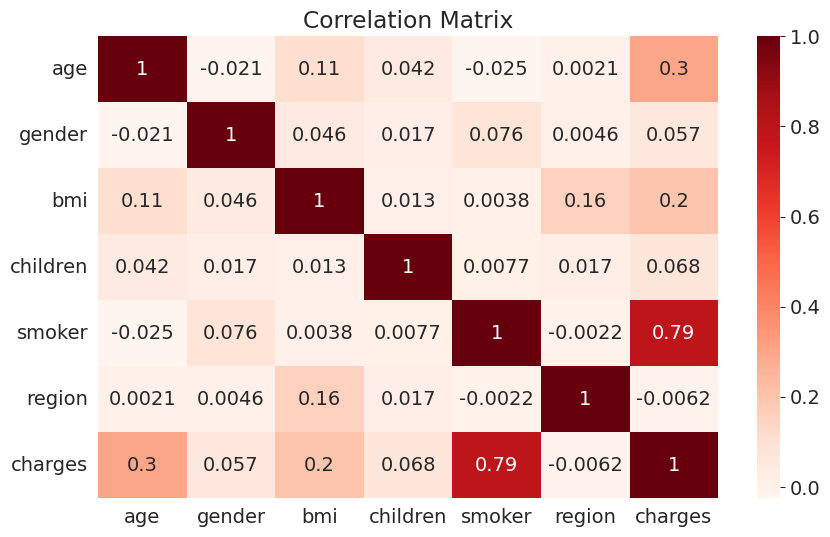

In [32]:
sns.heatmap(medical_df.corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix')